I got help from this chat: https://gapgpt.app/share/55d97fc2-22e9-481c-aa6c-e59e05741edb

Running on: cpu
Downloading/Loading CIFAR-10 dataset...

================ Scenario A: Low Bandwidth (1 Mbps) ================
--- Running SGD on Scenario A: Low Bandwidth (1 Mbps) ---
Epoch 1/20 | Loss: 2.289 | Acc: 15.45% | Sim Time: 275.74s
Epoch 2/20 | Loss: 2.181 | Acc: 21.00% | Sim Time: 551.48s
Epoch 3/20 | Loss: 2.025 | Acc: 28.60% | Sim Time: 827.21s
Epoch 4/20 | Loss: 1.880 | Acc: 33.75% | Sim Time: 1102.95s
Epoch 5/20 | Loss: 1.774 | Acc: 37.15% | Sim Time: 1378.69s
Epoch 6/20 | Loss: 1.714 | Acc: 38.10% | Sim Time: 1654.43s
Epoch 7/20 | Loss: 1.677 | Acc: 39.40% | Sim Time: 1930.16s
Epoch 8/20 | Loss: 1.558 | Acc: 43.30% | Sim Time: 2205.90s
Epoch 9/20 | Loss: 1.501 | Acc: 45.50% | Sim Time: 2481.64s
Epoch 10/20 | Loss: 1.392 | Acc: 49.40% | Sim Time: 2757.38s
Epoch 11/20 | Loss: 1.297 | Acc: 51.85% | Sim Time: 3033.11s
Epoch 12/20 | Loss: 1.233 | Acc: 55.30% | Sim Time: 3308.85s
Epoch 13/20 | Loss: 1.212 | Acc: 56.75% | Sim Time: 3584.59s
Epoch 14/20 | Loss: 1.084 | Acc: 61

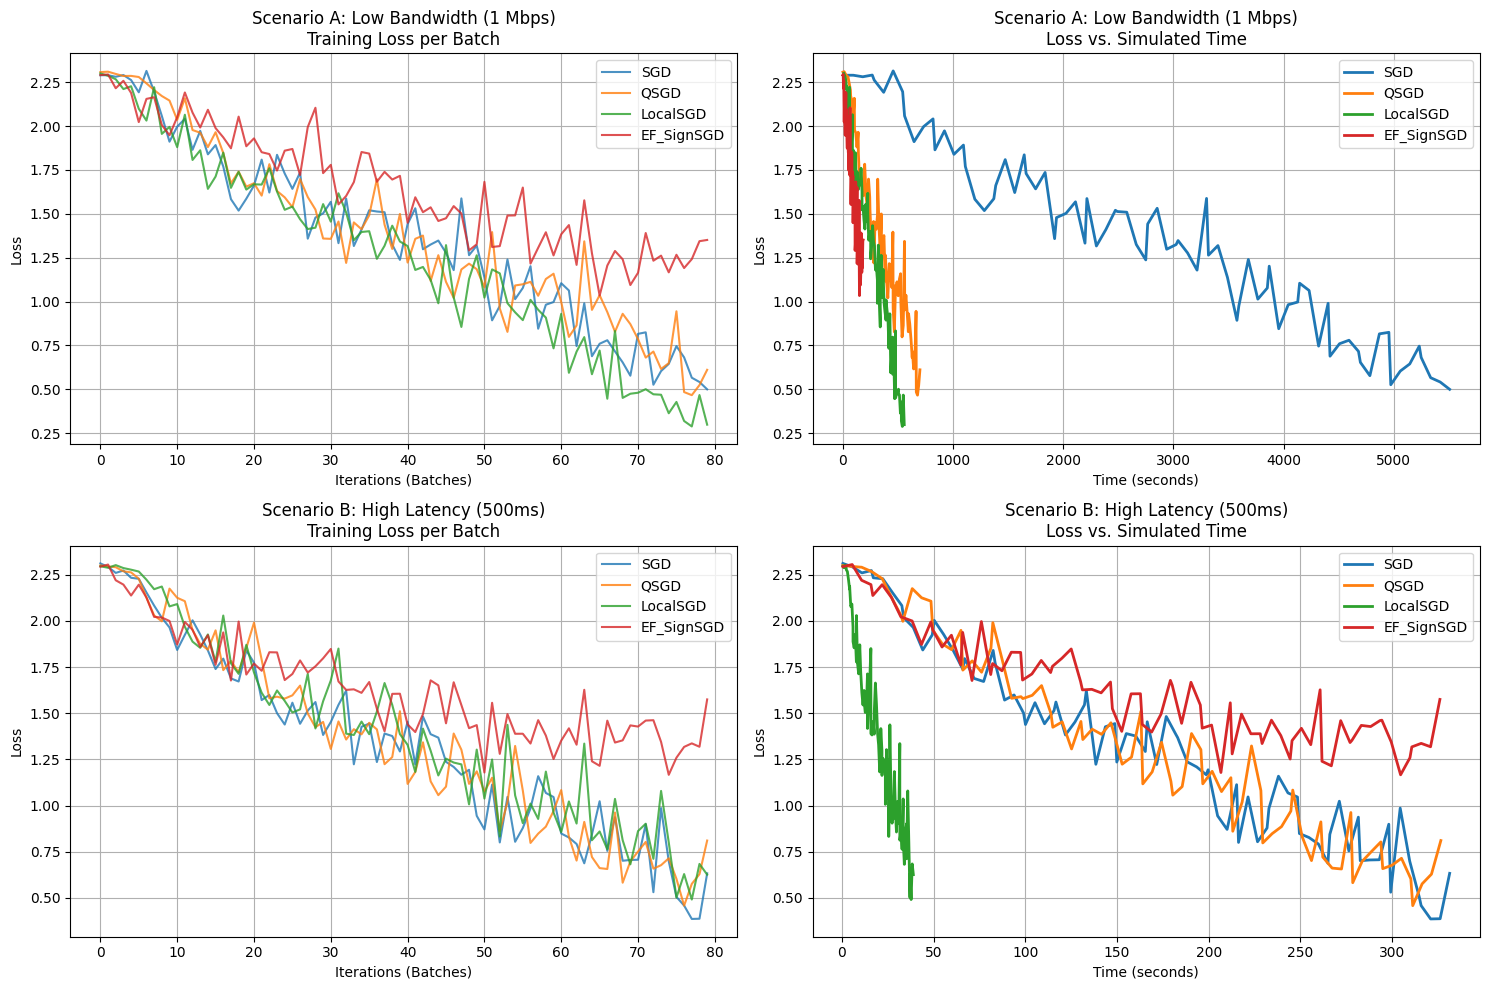

Done! Charts generated.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import copy
import time

# تنظیمات برای تکرارپذیری
torch.manual_seed(42)
np.random.seed(42)

# تشخیص دستگاه (GPU یا CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")

# ==========================================
# 1. تعریف مدل CNN و آماده‌سازی داده CIFAR-10
# ==========================================

# تنظیمات دیتاست
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# دانلود دیتاست (فقط بار اول طول می‌کشد)
print("Downloading/Loading CIFAR-10 dataset...")
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
# برای سرعت بیشتر شبیه‌سازی، از زیرمجموعه دیتاست استفاده می‌کنیم
# (برای پروژه نهایی می‌توانید این خط را حذف کنید تا روی کل دیتاست اجرا شود)
subset_indices = list(range(0, 2000))
trainset = torch.utils.data.Subset(trainset, subset_indices)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64,
                                          shuffle=True, num_workers=0)

# تعریف مدل CNN ساده
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 32 * 8 * 8)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# ==========================================
# 2. توابع فشرده‌سازی (Compression Utils)
# ==========================================

def quantize_qsgd(tensor, num_bits=4):
    """QSGD Quantization"""
    levels = 2 ** num_bits - 1
    norm = tensor.norm()
    if norm == 0: return tensor
    abs_tensor = tensor.abs()
    level_float = (abs_tensor / norm) * levels
    quantized = level_float.floor() + (torch.rand_like(tensor) < (level_float - level_float.floor())).float()
    return quantized * (norm / levels) * tensor.sign()

def sign_compress(tensor):
    """SignSGD Compression"""
    return torch.sign(tensor)

def calc_comm_time(size_bytes, bandwidth_mbps, latency_sec):
    """Time = Latency + (Size_bits / Bandwidth)"""
    size_bits = size_bytes * 8
    transfer_time = size_bits / (bandwidth_mbps * 1e6)
    return latency_sec + transfer_time

# ==========================================
# 3. شبیه‌سازی اصلی (Training Loop)
# ==========================================

def run_experiment(method, net_params, epochs=10):
    print(f"--- Running {method} on {net_params['name']} ---")

    model = SimpleCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    # بافر خطا برای EF
    error_buffer = {n: torch.zeros_like(p) for n, p in model.named_parameters()}

    # لاگ‌ها
    metrics = {'time': [0], 'loss': [], 'accuracy': []}
    current_sim_time = 0.0

    local_steps_K = 10 if method == 'LocalSGD' else 1
    global_step = 0

    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for i, data in enumerate(trainloader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)
            optimizer.zero_grad()

            # Forward + Backward
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()

            # آمارگیری
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # --- بخش شبیه‌سازی ارتباطات ---
            comm_overhead = 0.0

            # فقط در گام‌های سینک ارتباط داریم
            if global_step % local_steps_K == 0:
                total_bytes_sent = 0

                with torch.no_grad():
                    for name, p in model.named_parameters():
                        if p.grad is None: continue
                        grad = p.grad

                        # 1. Error Feedback Addition
                        if method == 'EF_SignSGD':
                            grad = grad + error_buffer[name]

                        # 2. Compression
                        if method == 'QSGD':
                            # 4-bit quantization (0.5 byte per elem ideally, here sim)
                            p.grad = quantize_qsgd(grad, num_bits=4)
                            # Size: num_elements * 0.5 bytes (4 bits) + metadata
                            total_bytes_sent += p.numel() * 0.5

                        elif method == 'EF_SignSGD':
                            compressed = sign_compress(grad)
                            # Update Buffer: Error = Actual - Compressed
                            error_buffer[name] = grad - compressed
                            # Update Grad
                            p.grad = compressed
                            # Size: num_elements * 0.125 bytes (1 bit)
                            total_bytes_sent += p.numel() / 8.0

                        else: # SGD or LocalSGD (Full Precision)
                            # Size: num_elements * 4 bytes (32 bit float)
                            total_bytes_sent += p.numel() * 4

                # محاسبه زمان بر اساس مدل شبکه
                if method == 'LocalSGD' and global_step % local_steps_K != 0:
                     comm_overhead = 0 # No communication
                else:
                     comm_overhead = calc_comm_time(total_bytes_sent,
                                                  net_params['bw'],
                                                  net_params['lat'])

            # اضافه کردن زمان محاسبات (ثابت فرض شده) + زمان ارتباط
            comp_time = 0.01 # فرض: 10 میلی‌ثانیه برای هر بچ
            current_sim_time += comp_time + comm_overhead

            optimizer.step()
            global_step += 1

            # ذخیره لاگ هر 10 بچ
            if i % 10 == 0:
                metrics['loss'].append(loss.item())
                metrics['time'].append(current_sim_time)

        # محاسبه دقت در پایان هر epoch
        acc = 100 * correct / total
        metrics['accuracy'].append(acc)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss/len(trainloader):.3f} | Acc: {acc:.2f}% | Sim Time: {current_sim_time:.2f}s")

    return metrics

# ==========================================
# 4. اجرای سناریوها
# ==========================================

# سناریو 1: پهنای باند کم (Low Bandwidth) -> QSGD باید خوب باشد
# سناریو 2: تاخیر بالا (High Latency) -> LocalSGD باید خوب باشد

scenarios = [
    {
        "name": "Scenario A: Low Bandwidth (1 Mbps)",
        "bw": 1,     # 1 Mbps (Very slow)
        "lat": 0.01  # 10ms (Low latency)
    },
    {
        "name": "Scenario B: High Latency (500ms)",
        "bw": 1000,  # 1 Gbps (Fast)
        "lat": 0.5   # 500ms (Very high latency)
    }
]

methods = ['SGD', 'QSGD', 'LocalSGD', 'EF_SignSGD']
results = {}

for scen in scenarios:
    scen_name = scen['name']
    results[scen_name] = {}
    print(f"\n================ {scen_name} ================")
    for method in methods:
        results[scen_name][method] = run_experiment(method, scen, epochs=20)

# ==========================================
# 5. رسم نمودار نهایی
# ==========================================
print("\nPlotting results...")
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for idx, scen in enumerate(scenarios):
    ax_loss = axes[idx][0]
    ax_time = axes[idx][1]

    scen_name = scen['name']

    # نمودار 1: Loss vs Iteration (همگرایی ریاضی)
    for method in methods:
        data = results[scen_name][method]
        ax_loss.plot(data['loss'], label=method, alpha=0.8)

    ax_loss.set_title(f"{scen_name}\nTraining Loss per Batch")
    ax_loss.set_xlabel("Iterations (Batches)")
    ax_loss.set_ylabel("Loss")
    ax_loss.grid(True)
    ax_loss.legend()

    # نمودار 2: Loss vs Wall-clock Time (کارایی واقعی)
    for method in methods:
        data = results[scen_name][method]
        # تطبیق طول آرایه‌ها
        min_len = min(len(data['time'][1:]), len(data['loss']))
        ax_time.plot(data['time'][1:][:min_len], data['loss'][:min_len], label=method, linewidth=2)

    ax_time.set_title(f"{scen_name}\nLoss vs. Simulated Time")
    ax_time.set_xlabel("Time (seconds)")
    ax_time.set_ylabel("Loss")
    ax_time.grid(True)
    ax_time.legend()

    # زوم کردن روی محور زمان برای دیدن تفاوت‌ها
    # ax_time.set_xlim(0, 100) # اگر نمودار خیلی کشیده بود، این را فعال کنید

plt.tight_layout()
plt.show()

print("Done! Charts generated.")
